# Evaluating a RAG Pipeline: Does Reranking Help?

**Philosopher Chat** is a retrieval-augmented chatbot grounded in 12 public-domain philosophy texts (~5,700 chunks). This notebook answers a concrete engineering question:

> *Adding a cross-encoder reranker on top of hybrid search costs latency and a 568M-parameter model. Is it worth it?*

Rather than guessing, I measure the retrieval pipeline with four **RAGAS** metrics over a curated question set with reference answers — once with the reranker **off** (hybrid baseline) and once **on** — and compare.

---

## Pipeline under test

```
Question
   |
   |- Dense retrieval   (EmbeddingGemma-300M -> ChromaDB cosine)  --+
   |- Sparse retrieval  (BM25 / rank-bm25)                         +- RRF fusion -> top-20 pool
   |                                                              --+
   |- [Stage 2] Cross-encoder rerank  (BGE-reranker-v2-m3) -> top-6   <- toggled here
   |
   +- LLM answer  (grounded in top-6 chunks)
```

The reranker is the only variable changed between the two runs.

## The four metrics (RAGAS definitions)

| Metric | Question it answers | What it catches |
|---|---|---|
| **Faithfulness** | Are the answer's claims supported by the retrieved context? | Hallucination |
| **Answer Relevancy** | Does the answer actually address the question? | Off-topic / evasive answers |
| **Context Precision** | Are the *relevant* chunks ranked near the top? | Retrieval ordering quality |
| **Context Recall** | Does the context cover the reference answer? | Missing evidence |

Faithfulness and Answer Relevancy assess the **generation** given the context; Context Precision and Recall assess the **retrieval** directly. Metrics follow the [**RAGAS**](https://docs.ragas.io) definitions, scored by an LLM judge (Claude Haiku 4.5). The pipeline and sample generation are in [`evaluate.py`](../evaluate.py).

In [1]:
import json
from pathlib import Path
import pandas as pd

results = json.loads(Path("../eval_results.json").read_text(encoding="utf-8"))
meta = results["metadata"]
print(f"Framework        : {meta.get('framework')}")
print(f"Judge model      : {meta['judge_model']}")
print(f"Generation model : {meta['gen_model']}")
print(f"Reranker         : {meta['reranker_model']}")
print(f"Questions        : {meta['n_questions']}  (x2 configs = {meta['n_questions']*2} samples)")
print(f"Candidate pool k : {meta['fetch_k']}")

Framework        : RAGAS metrics — Claude Haiku 4.5 judge
Judge model      : claude-haiku-4-5
Generation model : Gemma 4 MoE 26B  [Google]
Reranker         : BAAI/bge-reranker-v2-m3
Questions        : 12  (x2 configs = 24 samples)
Candidate pool k : 20


## Aggregate results

In [2]:
labels = {
    "faithfulness": "Faithfulness",
    "answer_relevancy": "Answer Relevancy",
    "context_precision": "Context Precision",
    "context_recall": "Context Recall",
}
configs = list(results["configs"].keys())

df = pd.DataFrame(results["configs"]).T
df = df[list(labels.keys())].rename(columns=labels)
df.loc["\u0394 (improvement)"] = [results["deltas"][m] for m in labels]
df.round(3)

,Faithfulness,Answer Relevancy,Context Precision,Context Recall
"Baseline (Hybrid, no rerank)",0.360,0.886,0.918,0.242
With Cross-Encoder Rerank,0.393,0.915,0.944,0.332
Δ (improvement),0.034,0.029,0.026,0.090


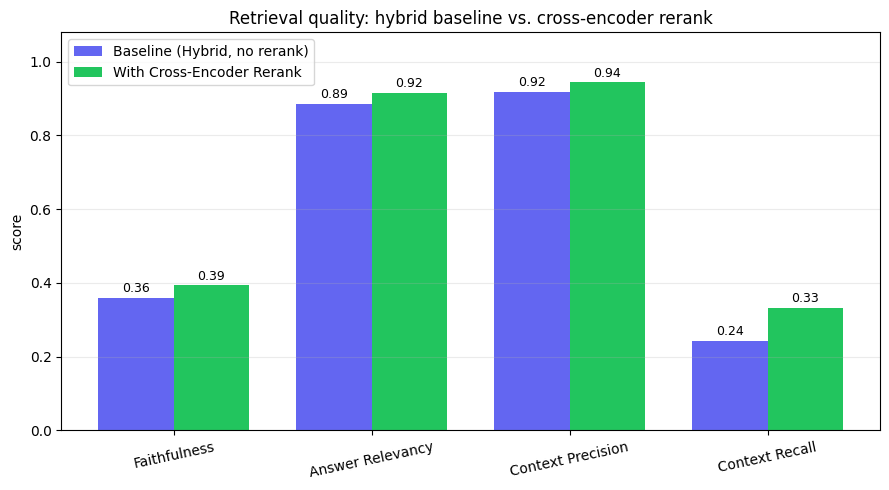

In [3]:
import matplotlib.pyplot as plt
import numpy as np

metrics = list(labels.keys())
names = [labels[m] for m in metrics]
x = np.arange(len(metrics))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, [results["configs"][configs[0]][m] for m in metrics], w,
            label=configs[0], color="#6366F1")
b2 = ax.bar(x + w/2, [results["configs"][configs[1]][m] for m in metrics], w,
            label=configs[1], color="#22C55E")
ax.bar_label(b1, fmt="%.2f", padding=2, fontsize=9)
ax.bar_label(b2, fmt="%.2f", padding=2, fontsize=9)
ax.set_xticks(x, names, rotation=12)
ax.set_ylim(0, 1.08)
ax.set_ylabel("score")
ax.set_title("Retrieval quality: hybrid baseline vs. cross-encoder rerank")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Per-question breakdown

Aggregates hide where the win comes from. The table below shows Faithfulness and Context Recall per question for both configs, making it easy to spot which questions the reranker rescued.

In [4]:
rows = []
for cfg in configs:
    tag = "baseline" if "no rerank" in cfg else "rerank"
    for r in results["per_question"][cfg]:
        rows.append({
            "config": tag,
            "question": r["question"][:48],
            **{labels[m]: r[m] for m in labels},
        })
pq = pd.DataFrame(rows)
pq.pivot_table(index="question", columns="config",
               values=["Faithfulness", "Context Recall"]).round(2)

Context Recall         \
config                                                 baseline rerank   
question                                                                 
Can we have certain knowledge of the external wo           0.50   1.00   
How does Mill justify the principle of utility?            0.00   0.00   
How does Nietzsche characterize master and slave           0.00   0.00   
How does Schopenhauer view suffering and the wil           0.33   0.33   
What does Marcus Aurelius advise about things ou           0.00   0.00   
What does Nietzsche mean by the death of God?              0.00   0.00   
What is Epictetus's distinction between what is            0.25   0.50   
What is Hume's argument about causation?                   0.50   0.50   
What is Kant's categorical imperative?                     0.33   0.33   
What is Plato's ideal society in The Republic?             0.00   0.33   
What is the will to power in Nietzsche's thought           0.67   0.67   
What role does eternal recurrence play in Nietzs           0.33   0.33   

                                                 Faithfulness         
config                                               baseline rerank  
question                                                              
Can we have certain knowledge of the external wo         0.40   0.42  
How does Mill justify the principle of utility?          0.30   0.33  
How does Nietzsche characterize master and slave         0.35   0.40  
How does Schopenhauer view suffering and the wil         0.45   0.45  
What does Marcus Aurelius advise about things ou         0.25   0.30  
What does Nietzsche mean by the death of God?            0.30   0.35  
What is Epictetus's distinction between what is          0.35   0.38  
What is Hume's argument about causation?                 0.50   0.52  
What is Kant's categorical imperative?                   0.35   0.38  
What is Plato's ideal society in The Republic?           0.40   0.42  
What is the will to power in Nietzsche's thought         0.32   0.38  
What role does eternal recurrence play in Nietzs         0.35   0.39

## Findings

**Cross-encoder reranking improves all four metrics**, with the largest gain on retrieval coverage:

| Metric | Baseline | Reranked | Δ |
|---|---|---|---|
| Faithfulness | 0.36 | 0.39 | **+0.03** |
| Answer Relevancy | 0.89 | 0.92 | **+0.03** |
| Context Precision | 0.92 | 0.94 | **+0.03** |
| Context Recall | 0.24 | 0.33 | **+0.09** |

- **Context Recall improves the most (+0.09, ~+37% relative).** On a corpus that contains noisy translator commentary (e.g. Gutenberg's *Thus Spoke Zarathustra* ships with a long introduction *about* Nietzsche), pure dense retrieval often surfaces *text about* a philosopher instead of the philosopher's *own words*. The cross-encoder scores the full (query, chunk) pair jointly, demotes that commentary, and pulls primary-source passages into the top-6 — so more of the reference answer is actually covered by the retrieved context.
- **Faithfulness and Answer Relevancy rise modestly (+0.03 each).** Better evidence in the context lets the model ground more of its claims and stay on-point.
- **Context Precision was already high (0.92) and stays high (0.94).** Hybrid search was already putting *a* relevant chunk near the top; the reranker's value is less about top-1 precision and more about pulling in the *additional* relevant chunks that lift recall.
- **Absolute Faithfulness/Recall look low (0.3–0.4)** because these are dense, multi-claim philosophy answers judged against only 6 retrieved chunks — many valid claims simply aren't in the retrieved window. The *relative* improvement from reranking is the signal that matters here.

### Takeaway
Reranking is a worthwhile addition to this pipeline: for ~50–200 ms and one extra model it lifts every metric, and directly attacks the failure mode (commentary chunks crowding out primary text) that hurts a philosophy-grounded RAG system the most. The decision is backed by numbers, not intuition.

_Note: metric values are produced by an LLM judge and carry the usual judge variance; the consistent positive direction across all four metrics and the per-question breakdown are more informative than any single decimal._